In [7]:
#1 - read in data set

import pandas as pd

df = pd.read_csv("data/project_dataset.csv")
df.shape

(130, 65)

In [8]:
#2 — import libraries
import numpy as np  # for data
import pandas as pd  # for data
import matplotlib.pyplot as plt  # for plots
import re

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report


In [9]:
df.describe()  # gives overview of data descriptions

,Age (years),Levodopa equivalent (mg/day),Clonazepam (mg/day),Entropy of speech timing (-),Rate of speech timing (-/min),Acceleration of speech timing (-/min2),Duration of pause intervals (ms),Duration of voiced intervals (ms),Gaping in-between voiced intervals (-/min),Duration of unvoiced stops (ms),...,Acceleration of speech timing (-/min2) .1,Duration of pause intervals (ms) .1,Duration of voiced intervals (ms) .1,Gaping in-between voiced Intervals (-/min),Duration of unvoiced stops (ms) .1,Decay of unvoiced fricatives (‰/min) .1,Relative loudness of respiration (dB) .1,Pause intervals per respiration (-) .1,Rate of speech respiration (-/min) .1,Latency of respiratory exchange (ms) .1
count,130.000000,130.0,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,...,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.00000
mean,64.330769,0.0,0.044231,1.551169,327.276923,10.929769,166.646154,285.761538,53.262846,30.614538,...,1.573923,229.069231,321.392308,45.089692,27.913385,0.045946,-20.033077,4.457692,17.447000,145.20000
std,10.133518,0.0,0.216149,0.019759,47.384951,12.151568,46.487618,51.624885,15.606155,8.550477,...,5.005207,79.696828,73.037475,12.522043,7.645818,0.592294,3.298629,1.791490,4.070072,85.20749
min,34.000000,0.0,0.000000,1.446000,140.000000,-20.320000,96.000000,197.000000,13.720000,17.880000,...,-17.870000,117.000000,211.000000,14.680000,13.370000,-1.417000,-27.310000,1.500000,8.210000,15.00000
25%,58.250000,0.0,0.000000,1.546000,297.250000,3.520000,138.250000,257.000000,42.712500,24.622500,...,-1.527500,177.000000,278.000000,36.987500,22.380000,-0.350000,-22.202500,3.000000,14.570000,90.50000
50%,66.500000,0.0,0.000000,1.556000,335.500000,11.310000,156.000000,276.000000,52.675000,28.560000,...,1.270000,212.500000,312.000000,44.420000,26.875000,0.034000,-20.390000,4.000000,17.585000,127.50000
75%,72.000000,0.0,0.000000,1.563000,358.750000,17.847500,185.000000,304.000000,62.945000,34.750000,...,4.685000,263.250000,348.000000,53.532500,31.370000,0.427500,-17.887500,5.000000,19.892500,176.25000
max,83.000000,0.0,2.000000,1.574000,457.000000,43.370000,388.000000,663.000000,109.500000,64.000000,...,14.640000,611.000000,800.000000,74.160000,58.370000,1.916000,-8.860000,13.500000,28.880000,593.00000


In [10]:
#3 - checking dataset components
print(df.shape)            # shows number of rows and columns in dataset
print(df.isna().mean().mean())  # overall missing values rate to show how complete the dataset actually is
df.filter(like="UPDRS").head(5)  # check the "UPDRS" column exists and shows first 5 observations

# UPDRS = "unified Parkinson's disease rating scale = measures disease severity

(130, 65)
0.0


,Overview of motor examination: UPDRS III total (-)
0,8
1,22
2,19
3,24
4,54


In [11]:
#4 — load and normalise headers; create Group column
df = pd.read_csv("data/project_dataset.csv", na_values=["-"]) #converts any dashes in the dataset into missing values (NaN). Meaning these will not be treated as numerical values.

# Normalise headers - the dataset has a lot of double spaces so this fixes that issue
df.columns = [re.sub(r"\s+", " ", c).strip() for c in df.columns]

# Fix any escaped minus signs in string cells - turns them back into proper minus signs
df = df.map(lambda x: x.replace("\\-", "-") if isinstance(x, str) else x)

# Create groups from participant code prefix (PD/RBD/HC)
if "Participant code" not in df.columns:
    cand = [c for c in df.columns if "Participant" in c and "code" in c.lower()]
    assert len(cand) == 1, "Could not find 'Participant code' column."
    df.rename(columns={cand[0]: "Participant code"}, inplace=True)

df["Group"] = df["Participant code"].str.extract(r"^(PD|RBD|HC)")[0]
print("Group counts:\n", df["Group"].value_counts()) # prints the group counts for each group


Group counts:
 Group
RBD    50
HC     50
PD     30
Name: count, dtype: int64


In [42]:
#5 — select features and avoid leakage

# flags text columns as these are not numerical features that we want for the model
text_cols = {"Participant code", "Gender",
    "Positive history of Parkinson disease in family",
    "Antidepressant therapy", "Antiparkinsonian medication",
    "Antipsychotic medication", "Benzodiazepine medication", "Group"}

# Define columns to drop from the model input, because they leak diagnosis severity.
# these directly measure PD severity and using them would be meaningless for early biomarkers of PD.
leak_cols = [c for c in df.columns if ("UPDRS" in c) or ("Hoehn" in c) or re.match
            if ("UPDRS" in c) or ("Hoehn" in c) or re.match(r"^\d+\.", c)]

# Basic demographics that will be included
demo_cols = [c for c in df.columns if c in {"Age (years)", "Gender"}]

# build a list of numeric features: speech/respiration etc.
numeric_features = []
for c in df.columns:
    if c in text_cols or c in leak_cols: 
        continue
# try to treat as numeric
    try:
        pd.to_numeric(df[c])
        numeric_features.append(c)
    except Exception:
        pass

# build a list of categorical features to be included (only gender)
# Keep Gender as categorical
categorical_features = [c for c in demo_cols if c == "Gender"]

# which features remain in the model input
print("Numeric features (count):", len(numeric_features))
print("Categorical features:", categorical_features[:5])


Numeric features (count): 29
Categorical features: ['Gender']


In [43]:
#6 — preprocessing and models
from sklearn.preprocessing import OneHotEncoder

# for numeric features, fill the missing values with the median, then scale them.
# this keeps the features comparable
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())])

# for categorical features, fill the missing values with the most frequent value.
# one-hot encode Gender feature 
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop=None))])

# apply the correct steps to the correct columns
preprocess = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)],remainder="drop")

# Models
logreg = LogisticRegression(max_iter=2000, solver="lbfgs")
rf = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    min_samples_leaf=2, 
    random_state=42,
    n_jobs=-1)

# pipeline = 1. preprocess (column transfromer)  2. model (logistic regression or random forest classifier)
pipelines = {"LogisticRegression": Pipeline(steps=[("preprocess", preprocess), ("model", logreg)]),
    "RandomForest": Pipeline(steps=[("preprocess", preprocess), ("model", rf)]),}


In [44]:
#7 — Evaluating both models for each pair of groups (e.g., PD vs HC)

# subset the data into different groups (PD, HC, RBD)
def run_binary_comparison(df, group_a, group_b, label_name):
    """
    df: DataFrame with 'Group'
    group_a, group_b: strings in {'PD','RBD','HC'}
    label_name: e.g., 'PD_vs_HC'
    """
    sub = df[df["Group"].isin([group_a, group_b])].copy()
    sub["y"] = (sub["Group"] == group_a).astype(int)  # positive class = group_a

# apply features (X) and labels (y)
    X_feat = sub[numeric_features + categorical_features]
    y = sub["y"].values

# use a 5-fold cross-validation approach, keeping it stratified to ensure each split has the same proportions in each group.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    results = {}

# plot the ROC curves for both models across all folds and then average them.
    plt.figure(figsize=(5.5, 4))

# loop over both pipelines (LogisticRegression and RandomForest)
    for name, pipe in pipelines.items():
        aucs, y_true_all, y_pred_all = [], [], []
        mean_fpr = np.linspace(0, 1, 200)
        tprs = []

# split the data into train/test for each fold
        for train_idx, test_idx in cv.split(X_feat, y):
            X_train = X_feat.iloc[train_idx]
            X_test  = X_feat.iloc[test_idx]
            y_train = y[train_idx]
            y_test  = y[test_idx]

# fit the pipeline (preprocess + model)
            pipe.fit(X_train, y_train)

# decision_function (logistic regression) or predict_proba (Random Forest) for ROC scores
            if hasattr(pipe.named_steps["model"], "decision_function"):
                y_score = pipe.decision_function(X_test)
            else:
                y_score = pipe.predict_proba(X_test)[:, 1]

# ROC and AUC
            fpr, tpr, _ = roc_curve(y_test, y_score)
            aucs.append(auc(fpr, tpr))

# deterministic predictions for confusion matrix
            y_pred = pipe.predict(X_test)
            y_true_all.extend(y_test.tolist())
            y_pred_all.extend(y_pred.tolist())

# interpolate for mean ROC
            tpr_interp = np.interp(mean_fpr, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs.append(tpr_interp)

# aggregate results after all folds and average ROC curve and mean AUC
            mean_tpr = np.mean(tprs, axis=0)
            mean_tpr[-1] = 1.0
            mean_auc = np.mean(aucs)
            std_auc = np.std(aucs)

# compute confusion matrix & report across all test folds
        cm = confusion_matrix(y_true_all, y_pred_all)
        cr = classification_report(y_true_all, y_pred_all, output_dict=True)

        print(f"\n{label_name} — {name} confusion matrix (rows=true, cols=pred):\n{cm}")

# plot mean ROC for both models
        plt.plot(mean_fpr, mean_tpr, label=f"{name} (AUC={mean_auc:.3f}±{std_auc:.3f})")

    plt.plot([0,1], [0,1], "k--", alpha=0.5)
    plt.title(f"ROC: {group_a} vs {group_b}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()



PD_vs_HC — LogisticRegression confusion matrix (rows=true, cols=pred):
[[43  7]
 [16 14]]

PD_vs_HC — RandomForest confusion matrix (rows=true, cols=pred):
[[47  3]
 [11 19]]


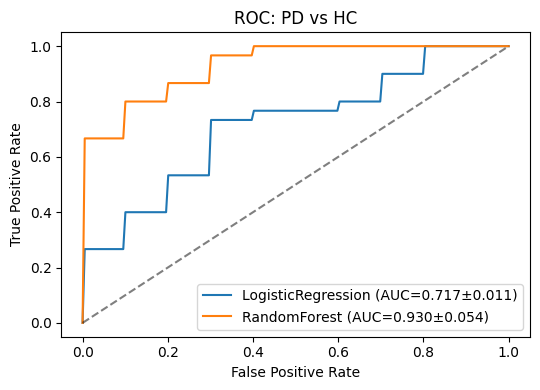


RBD_vs_HC — LogisticRegression confusion matrix (rows=true, cols=pred):
[[36 14]
 [15 35]]

RBD_vs_HC — RandomForest confusion matrix (rows=true, cols=pred):
[[43  7]
 [ 2 48]]


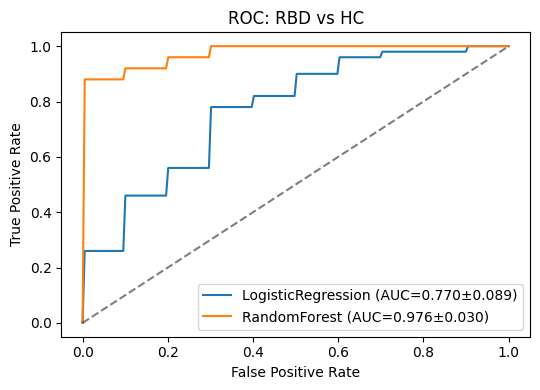


PD_vs_RBD — LogisticRegression confusion matrix (rows=true, cols=pred):
[[36 14]
 [17 13]]

PD_vs_RBD — RandomForest confusion matrix (rows=true, cols=pred):
[[43  7]
 [21  9]]


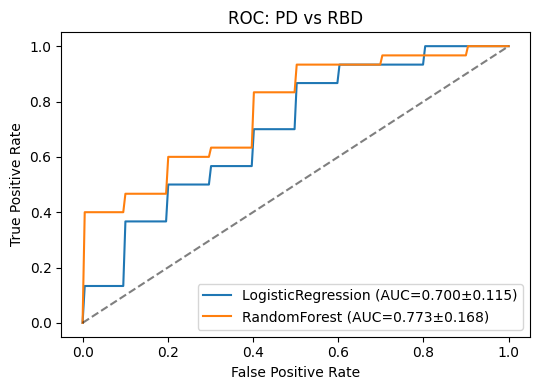

In [45]:
#8 — run binary comparison for all 3 groups (PD, RBD, HC)

res_PD_HC  = run_binary_comparison(df, "PD",  "HC",  "PD_vs_HC")
res_RBD_HC = run_binary_comparison(df, "RBD", "HC",  "RBD_vs_HC")
res_PD_RBD = run_binary_comparison(df, "PD",  "RBD", "PD_vs_RBD")


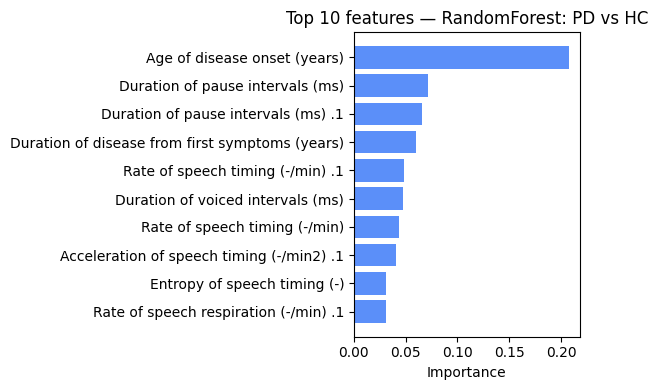

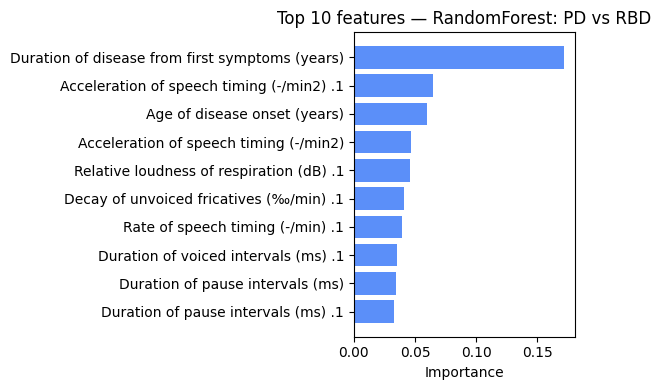

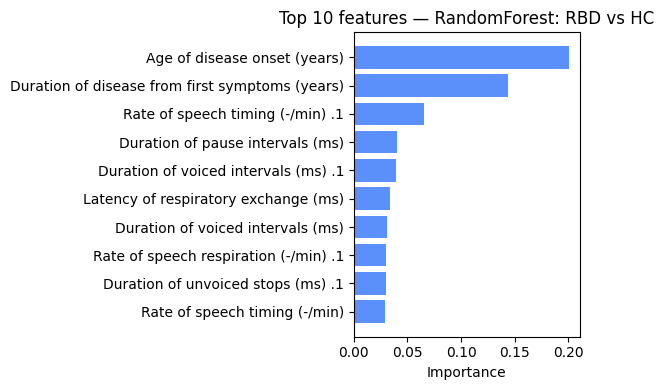

In [48]:
#9 — feature importance 

def get_feature_names(preprocess):
# Extract the original feature names from before they were transformed
    num_names = preprocess.transformers_[0][2]
    cat_pipeline = preprocess.transformers_[1][1]
    cat_cols = preprocess.transformers_[1][2]
# recover onehot encoded feature names:
    ohe = cat_pipeline.named_steps["onehot"]
    ohe_names = ohe.get_feature_names_out(cat_cols)
    return list(num_names) + list(ohe_names)

# subsets the dataframe to the 2 groups it is comparing. it fits the pipeline to the subset
def fit_and_importances(df, group_a, group_b, model_name, top_n=10):
    sub = df[df["Group"].isin([group_a, group_b])].copy()
    sub["y"] = (sub["Group"] == group_a).astype(int)
    X = sub[numeric_features + categorical_features]
    y = sub["y"].values

    pipe = pipelines[model_name]
    pipe.fit(X, y)

# Get feature names after preprocessing
    feat_names = get_feature_names(pipe.named_steps["preprocess"])

# importances that are model-specific
    if model_name == "LogisticRegression":
# coefficients (absolute value)
        coef = pipe.named_steps["model"].coef_.ravel()
        importances = np.abs(coef)
    else:  # RandomForest
        importances = pipe.named_steps["model"].feature_importances_

# pick the top 10 importances and plot them on a bar chart
    order = np.argsort(importances)[::-1]
    top_idx = order[:top_n]
    top_feats = [(feat_names[i], float(importances[i])) for i in top_idx]

# Plot
    plt.figure(figsize=(6, 4))
    plt.barh([f for f, _ in reversed(top_feats)], [v for _, v in reversed(top_feats)], color="#5B8FF9")
    plt.title(f"Top {top_n} features — {model_name}: {group_a} vs {group_b}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    
    return top_feats

# Generate all 6 importance plots for both models & all comparisons
_ = fit_and_importances(df, "PD",  "HC",  "RandomForest",       10)
_ = fit_and_importances(df, "PD",  "RBD", "RandomForest",       10)
_ = fit_and_importances(df, "RBD", "HC",  "RandomForest",       10)
